# An introduction to AlTar: the linear model

In this tutorial we use a linear model, $\mathbf d = \mathbf G \boldsymbol\theta$, to show how an
AlTar application is built, configured and run, and how to look at its results. The linear model
with a Gaussian prior has a posterior we can write down exactly, so we can also check the samples
AlTar draws against it.

## 1. Bayesian inference with AlTar

A forward model $\mathbf d = G(\boldsymbol\theta)$ predicts the observations $\mathbf d$ from a
set of parameters $\boldsymbol\theta$. The inverse problem asks for the $\boldsymbol\theta$ that
explain some observed $\mathbf d$; in general $G$ can't be inverted directly, and the data come
with uncertainties anyway. Bayesian inference answers with a probability instead, from Bayes'
theorem,

$$
P(\boldsymbol\theta|\mathbf d) \propto P(\mathbf d|\boldsymbol\theta)\, P(\boldsymbol\theta),
$$

the posterior, the product of the data likelihood $P(\mathbf d|\boldsymbol\theta)$, computed with
the forward model, and the prior $P(\boldsymbol\theta)$. AlTar draws samples of the posterior with
Markov chain Monte Carlo (MCMC) methods. Its default, [CATMIP](https://thesis.library.caltech.edu/5918/),
anneals a large number of chains through the transitional distributions

$$
P_m(\boldsymbol\theta|\mathbf d) \propto P(\mathbf d|\boldsymbol\theta)^{\beta_m} P(\boldsymbol\theta),
\qquad 0 = \beta_0 < \beta_1 < \dots < \beta_M = 1,
$$

from the prior to the posterior.

An AlTar application is built from [pyre](https://github.com/pyre/pyre) components, each of which
can be configured, or swapped for another implementation, without changing any code. The main
ones are

- `model`: the forward model and the observed data. Its parameters are grouped into parameter
  sets, `psets`, each with a `prior`, and a `prep` distribution to draw the initial samples from;
  the observations, their covariance and the L2 norm of the misfit are in `dataobs`.
- `controller`: how the posterior is sampled. `altar.bayesian.catmip` is the CATMIP annealer,
  with
  - `scheduler`: picks the next $\beta$ from the coefficient of variation (COV) of the
    importance weights, which keeps the effective sample size near 50%;
  - `sampler`: updates the chains at each $\beta$, by default with Metropolis steps, with a
    Gaussian proposal whose covariance is estimated from the samples;
  - `archiver`: saves the results, in memory (`recorder`, the default) or to HDF5 files
    (`h5recorder`).
- `job`: the size of the run and where it runs: the number of chains, the number of MCMC steps at
  each $\beta$, the number of processes, CPU or GPU.
- `rng`: the random number generator.

See [the AlTar framework](../../guide/AlTarFramework.md) for all of them.

## 2. An application for the linear model

The forward model of the linear model is $\mathbf d = \mathbf G \boldsymbol\theta$, with the
Green's functions $\mathbf G$, a matrix of shape (observations, parameters). We create an
application whose model is the linear model by default:

In [1]:
import altar
import altar.models.linear

# an altar application that uses the linear model by default
class LinearApp(altar.shells.altar, family='altar.applications.linear'):
    """
    A specialized AlTar application that exercises the Linear model
    """
    # user configurable component
    model = altar.models.model(default='linear')

The settings come from a configuration file. An application looks for one named after the
instance, so the instance `linear` we create below reads [linear.pfg](linear.pfg):

In [2]:
print(open('linear.pfg').read())

;
; (c) 2013-present parasim inc
; (c) 2010-present california institute of technology
; all rights reserved
;

; the linear model tutorial: sample the posterior of d = G θ with CATMIP
linear:
    ; the model
    model = altar.models.linear
    model:
        ; the name of the test case, also the directory with the input files
        case = patch-9
        ; the number of free parameters
        parameters = 18
        ; the green's functions, (observations, parameters)
        green = green.txt

        ; the observed data, and their covariance
        dataobs:
            observations = 108
            data_file = data.txt
            cd_file = cd.txt

        ; a single parameter set covering the whole vector
        psets_list = [all]
        psets:
            all = contiguous
            all:
                count = {linear.model.parameters}
                ; the distribution the samples are drawn from at β = 0
                prep = gaussian
                prep.sigma = 0.5
   

The model reads its inputs from the directory `case`, `patch-9`: the Green's functions
`green.txt`, the observations `data.txt`, and their covariance `cd.txt`. We have 18 parameters,
each with a Gaussian prior of mean 0 and standard deviation 0.5, and 108 observations. Any setting
left out keeps its default; see the [Quick Start](../../guide/QuickStart.md) for more on the
configuration file.

## 3. Sample the posterior

We create the application, initialize its components, and let the model sample its posterior. At
each $\beta$ step, AlTar prints the step's $\beta$ and the mean and standard deviation of each
parameter; only the first step is kept below.

In [3]:
# create an instance, configured by linear.pfg
myapp = LinearApp(name='linear')
# initialize its components
myapp.initialize()
# and sample the posterior with CATMIP
status = myapp.model.posterior(application=myapp)

journal (altar):
 -- time: 2026-09-28T21:15:36.387364
journal (altar):
 -- iteration: 0, beta: 0, scaling: 0.1
journal (altar):
 -- stats(accepted/invalid/rejected): (0, 0, 0)
journal (altar):
 -- step
 --   β: 0
 --   θ_sampling: (1024 samples) x (18 parameters)
 --   parameters (mean, sd):
 --    (0.018337881631437083, 0.5052453298270653)
 --    (0.014805859520560022, 0.4766894664140216)
 --    (-0.01462564513078194, 0.5081654158571511)
 --    (-0.002355673369142845, 0.5081162163836722)
 --    (-0.04118865774270952, 0.5073394241501916)
 --    (0.0017552032804668066, 0.5083596919672608)
 --    (-0.0020480581810896586, 0.49203214603015305)
 --    (0.006802537886870903, 0.5050897094148948)
 --    (0.019792637990626735, 0.5078926959999586)
 --    (-0.014077530688462712, 0.5285959116127767)
 --    (-0.01637361479187935, 0.5061220237476346)
 --    (0.009529041379845204, 0.4866321830486042)
 --    (0.0005823928357463203, 0.5064351771426218)
 --    (0.018808766714457793, 0.4980890641425079)


The history of the annealing, one line per $\beta$ step with the scaling of the proposal and
the Metropolis statistics, is in `results/BetaStatistics.txt`:

In [4]:
print(open('results/BetaStatistics.txt').read())

iteration, beta, scaling, (accepted, invalid, rejected)
0, 0, 0.1, 0, 0, 0
1, 0.000152, 0.018216455380328088, 27320, 0, 5448
2, 0.0003769658, 0.03794815306929365, 31716, 0, 1052
3, 0.0006968451709439999, 0.076389488586429, 30593, 0, 2175
4, 0.0012264758430033996, 0.1419034795082503, 27961, 0, 4807
5, 0.0020954088090199864, 0.24563874699394816, 25648, 0, 7120
6, 0.003173145767506244, 0.3885049053529252, 22690, 0, 10078
7, 0.004429147603839187, 0.5131842270096343, 16788, 0, 15980
8, 0.006320732223391892, 0.5669916712568008, 10935, 0, 21833
9, 0.00921233889262182, 0.5858347362278032, 8739, 0, 24029
10, 0.013571804601494285, 0.588437999437687, 7813, 0, 24955
11, 0.019983587871584572, 0.5901696536741952, 7764, 0, 25004
12, 0.029293743786804518, 0.584564327976868, 7355, 0, 25413
13, 0.042883631373789255, 0.5849620697271591, 7690, 0, 25078
14, 0.06202595874631347, 0.5898791070064465, 7942, 0, 24826
15, 0.09016517998392407, 0.5911277271699792, 7737, 0, 25031
16, 0.13019791206463138, 0.58453136

## 4. The samples

The final state of the chains is the controller's `step`: $\beta$, the samples $\boldsymbol\theta$,
a matrix of shape (samples, parameters), and the log prior, log likelihood and log posterior of
each sample.

In [5]:
import numpy

# the final step
step = myapp.controller.worker.step
print('beta =', step.beta)
print('samples =', step.samples)
print('parameters =', step.parameters)
# the samples as a numpy array, (samples, parameters)
theta = numpy.asarray(step.theta)
mean, sd = theta.mean(axis=0), theta.std(axis=0)
print('posterior mean:', numpy.round(mean, 3))
print('posterior sd:  ', numpy.round(sd, 3))

beta = 1.0
samples = 1024
parameters = 18
posterior mean: [0.164 0.167 0.181 0.174 0.166 0.177 0.184 0.172 0.168 0.996 0.988 0.982
 0.865 1.014 0.982 0.999 0.983 0.982]
posterior sd:   [0.035 0.134 0.074 0.025 0.142 0.049 0.035 0.141 0.075 0.057 0.082 0.13
 0.309 0.141 0.193 0.058 0.087 0.129]


For a linear model with a Gaussian prior $\mathcal N(\boldsymbol\theta_0, \sigma^2 \mathbf I)$
and Gaussian data errors of covariance $\mathbf C_d$, the posterior is also Gaussian, with

$$
\boldsymbol\Sigma = \left(\mathbf G^T \mathbf C_d^{-1} \mathbf G + \sigma^{-2} \mathbf I\right)^{-1},
\qquad
\boldsymbol\mu = \boldsymbol\Sigma \left(\mathbf G^T \mathbf C_d^{-1} \mathbf d + \sigma^{-2} \boldsymbol\theta_0\right).
$$

Let's compare the samples with it:

In [6]:
# the inputs of the model
G = numpy.loadtxt('patch-9/green.txt')
d = numpy.loadtxt('patch-9/data.txt')
Cd = numpy.loadtxt('patch-9/cd.txt')
# the prior, as in linear.pfg
theta0, sigma = 0.0, 0.5

# the exact posterior
Cinv = numpy.linalg.inv(Cd)
Sigma = numpy.linalg.inv(G.T @ Cinv @ G + numpy.eye(G.shape[1]) / sigma**2)
mu = Sigma @ (G.T @ Cinv @ d + theta0 / sigma**2)
sd_exact = numpy.sqrt(numpy.diag(Sigma))

# the error of the sample mean, in units of the posterior sd, and the ratio of the sds
print('(mean - mu)/sd:', numpy.round((mean - mu) / sd_exact, 2))
print('sd/sd_exact:   ', numpy.round(sd / sd_exact, 2))

(mean - mu)/sd: [-0.02 -0.01 -0.03 -0.01 -0.03  0.03  0.03  0.01  0.01 -0.01  0.02  0.02
  0.04 -0.06 -0.04  0.02 -0.02  0.03]
sd/sd_exact:    [1.   0.97 0.97 1.02 0.96 0.97 1.01 1.02 0.98 0.99 0.97 1.02 1.02 1.01
 1.02 1.   1.02 1.02]


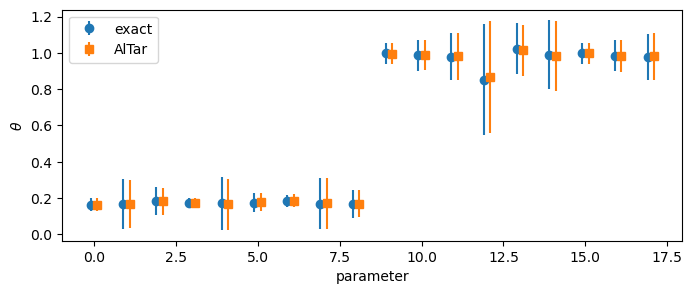

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
index = numpy.arange(G.shape[1])
ax.errorbar(index - 0.1, mu, yerr=sd_exact, fmt='o', label='exact')
ax.errorbar(index + 0.1, mean, yerr=sd, fmt='s', label='AlTar')
ax.set_xlabel('parameter')
ax.set_ylabel(r'$\theta$')
ax.legend()
plt.show()

The samples reproduce the exact mean and standard deviation, within the sampling error of 1024
samples. The histograms of the parameters best and least constrained by the data, against their
exact marginals:

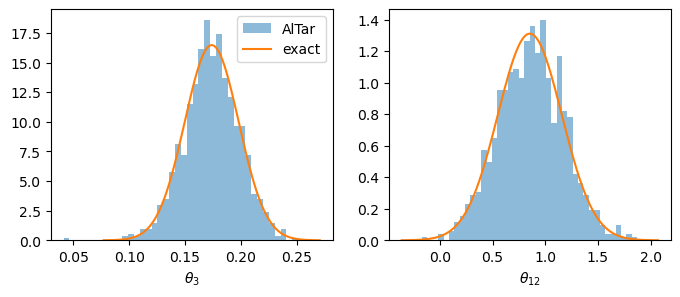

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, i in zip(axes, (numpy.argmin(sd_exact), numpy.argmax(sd_exact))):
    ax.hist(theta[:, i], bins=40, density=True, alpha=0.5, label='AlTar')
    x = numpy.linspace(mu[i] - 4*sd_exact[i], mu[i] + 4*sd_exact[i], 200)
    ax.plot(x, numpy.exp(-0.5*((x - mu[i])/sd_exact[i])**2) / (sd_exact[i]*numpy.sqrt(2*numpy.pi)),
            label='exact')
    ax.set_xlabel(rf'$\theta_{{{i}}}$')
axes[0].legend()
plt.show()

## 5. The output files

The `h5recorder` archiver saves each $\beta$ step to `results/step_nnn.h5`, and the posterior to
`results/step_final.h5`. The files can be read with `h5py`:

In [9]:
import h5py

with h5py.File('results/step_final.h5', 'r') as h5:
    # the groups in the file
    print('groups:', list(h5.keys()))
    print('Bayesian:', list(h5['Bayesian'].keys()))
    print('ParameterSets:', list(h5['ParameterSets'].keys()))
    # the samples of the parameter set 'all', (samples, parameters)
    theta_h5 = h5['ParameterSets/all_sampling'][:]
    # the log posterior of each sample
    posterior = h5['Bayesian/posterior'][:]

print('theta:', theta_h5.shape, ' posterior:', posterior.shape)
print('same samples as in memory:', numpy.allclose(theta_h5, theta))

groups: ['Annealer', 'Bayesian', 'ParameterSets', 'Proposal', 'Statistics']
Bayesian: ['likelihood', 'posterior', 'prior']
ParameterSets: ['all_sampling', 'has_reparametrization']
theta: (1024, 18)  posterior: (1024,)
same samples as in memory: True


The probabilities are saved as logarithms. The layout of the files is described in the
[Quick Start](../../guide/QuickStart.md).

## 6. Run from the command line

The same run from a shell uses the linear model's application, `altar-linear`, and any setting can
be changed on the command line:

```bash
altar-linear --config=linear.pfg
altar-linear --config=linear.pfg --job.chains=2**12 --job.gpus=1
```

The examples in `models/linear/examples` sample the same posterior with the other controllers,
e.g. `linear_mcmc.pfg`, `linear_hmc.pfg` and `linear_mala.pfg`. To try another configuration here,
edit `linear.pfg` and restart the kernel: the configuration is read when the application is
created.